# EDA, PCA, ad KMeans

## Data Loading and Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset.csv', na_values='?')

price_cols = ['open','high','low','close','next_weeks_open','next_weeks_close']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

df = df.drop(['stock', 'quarter', 'date', 'next_weeks_close'], axis=1).dropna().reset_index(drop=True)

X = df.copy()

print("Feature matrix shape:", X.shape)


Feature matrix shape: (720, 12)


## Exploratory Data Analysis

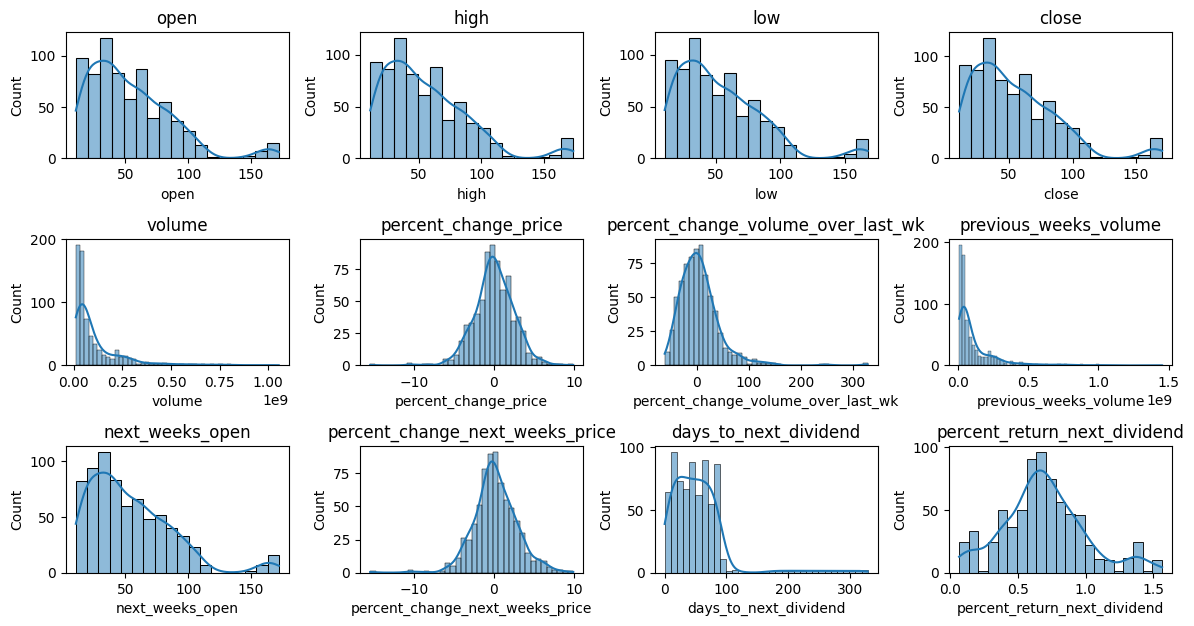

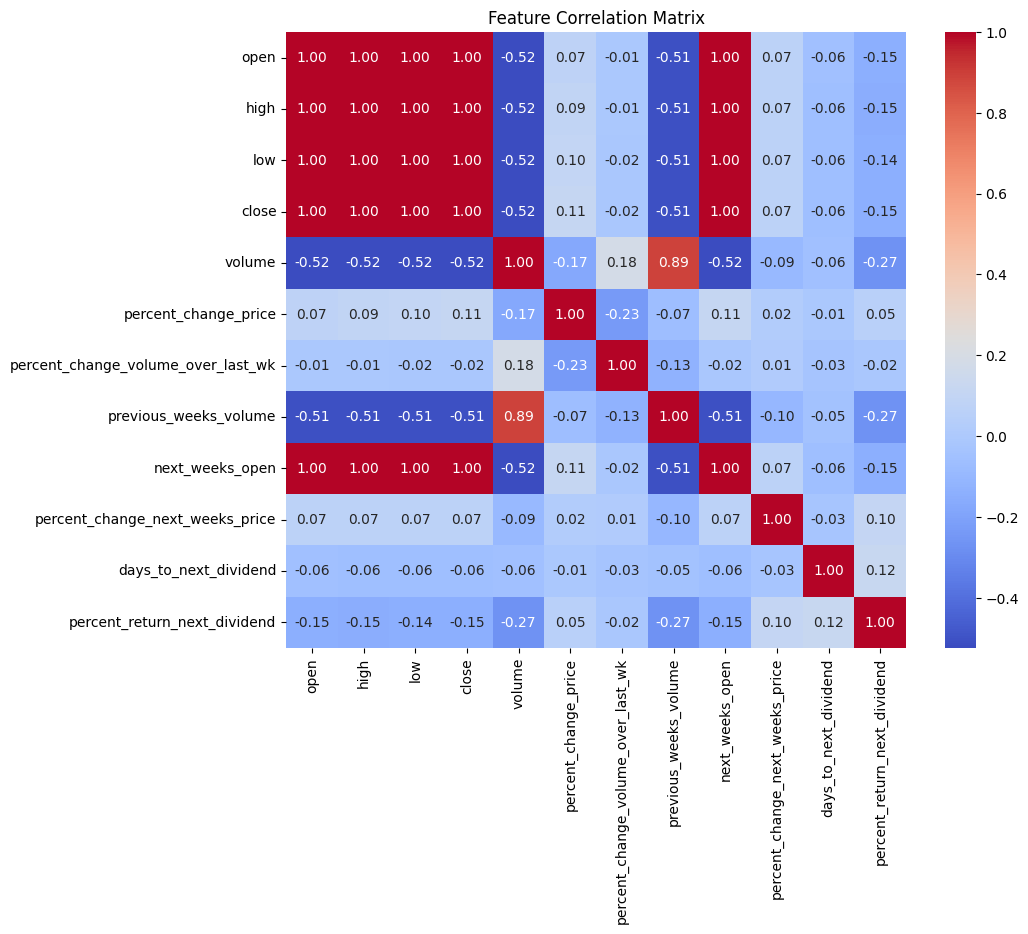

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
for i, col in enumerate(X.columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(X_scaled, columns=X.columns).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


## Dimensionality Reduction with PCA

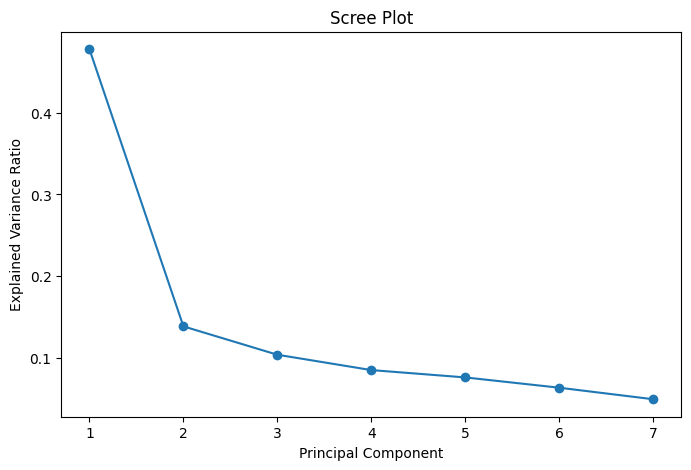

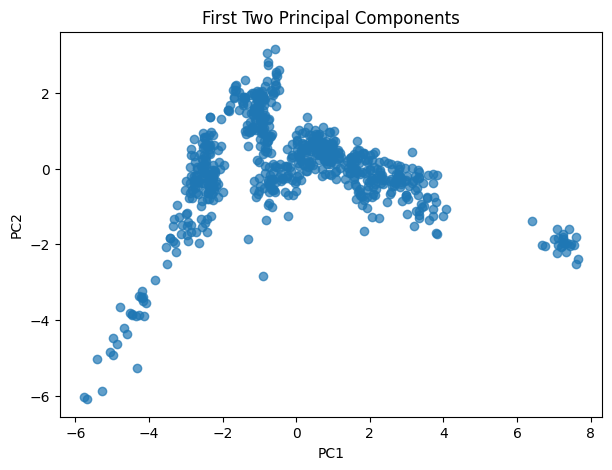

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.show()

# PC1 vs PC2 scatter
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('First Two Principal Components')
plt.show()


## Clustering with KMeans

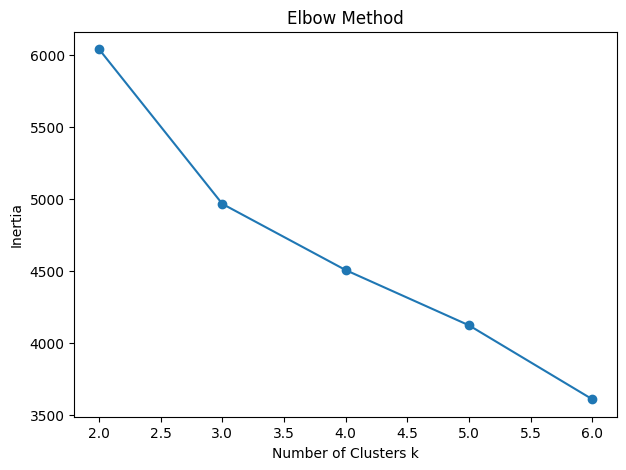

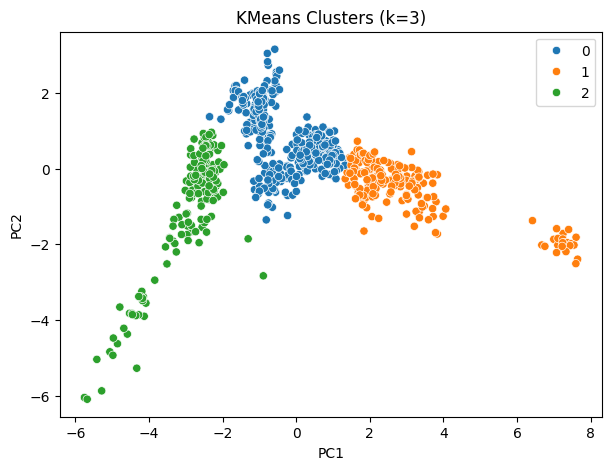

In [4]:
from sklearn.cluster import KMeans

inertias = []
ks = range(2, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Number of Clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42).fit(X_pca)
labels = kmeans.labels_

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'KMeans Clusters (k={k_opt})')
plt.show()


## Cluster Analysis

In [5]:
import pandas as pd
counts = pd.Series(labels).value_counts().sort_index()
display(pd.DataFrame({'Cluster': counts.index, 'Count': counts.values}))

centers = pd.DataFrame(kmeans.cluster_centers_, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
print("PCA-space cluster centers:")
display(centers)



,Cluster,Count
0,0,361
1,1,190
2,2,169


PCA-space cluster centers:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.254532,0.750069,0.067143,-0.034732,-0.121005,-0.040639,-0.083219
1,3.042336,-0.535648,-0.052710,0.017730,0.100328,0.000981,0.103086
2,-2.876672,-1.000011,-0.084164,0.054258,0.145684,0.085705,0.061869


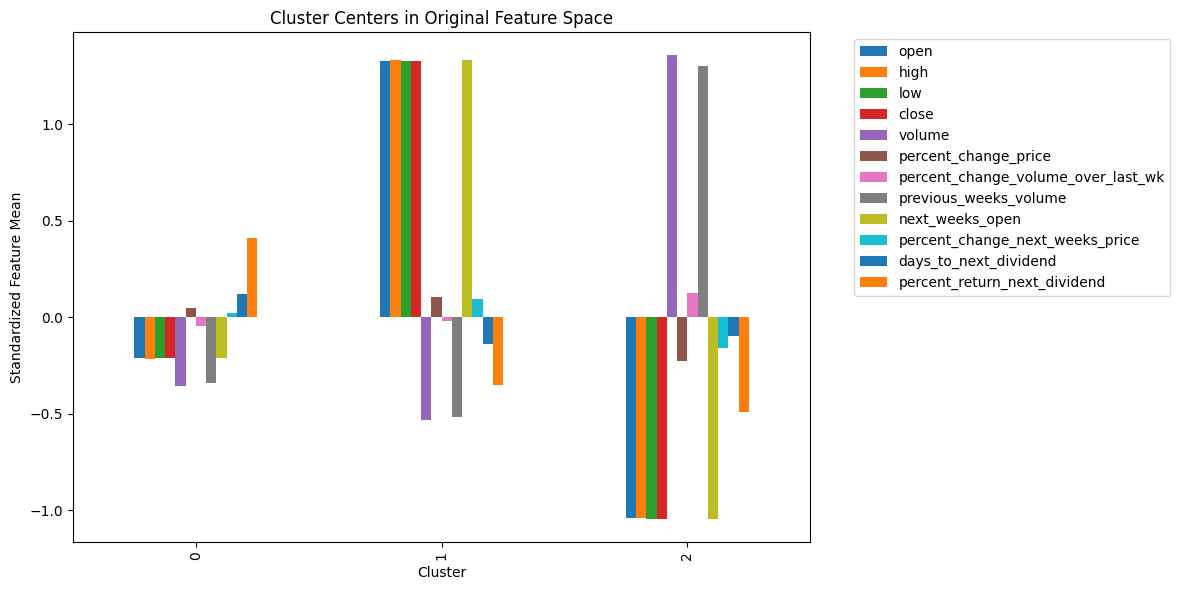

In [6]:
# labels projects to original standardized feature space
X_df = pd.DataFrame(X_scaled, columns=X.columns)
X_df['cluster'] = labels

cluster_means = X_df.groupby('cluster').mean()

cluster_means.plot(kind='bar', figsize=(12, 6))
plt.title('Cluster Centers in Original Feature Space')
plt.xlabel('Cluster')
plt.ylabel('Standardized Feature Mean')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

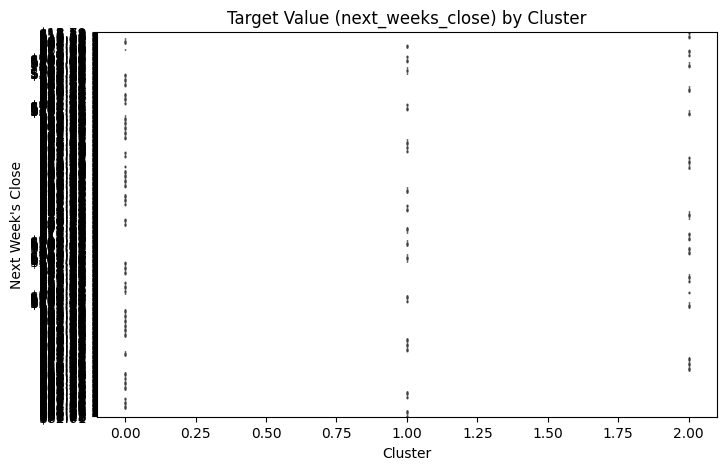

In [7]:
# reload full data
df_full = pd.read_csv('dataset.csv', na_values='?')
df_full = df_full.drop(['stock', 'quarter', 'date'], axis=1).dropna().reset_index(drop=True)

df_full = df_full.drop(['next_weeks_open', 'percent_change_next_weeks_price'], axis=1)

df_full['cluster'] = labels

# Plot boxplot of target vs cluster
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y='next_weeks_close', data=df_full)
plt.title('Target Value (next_weeks_close) by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Next Week\'s Close')
plt.show()

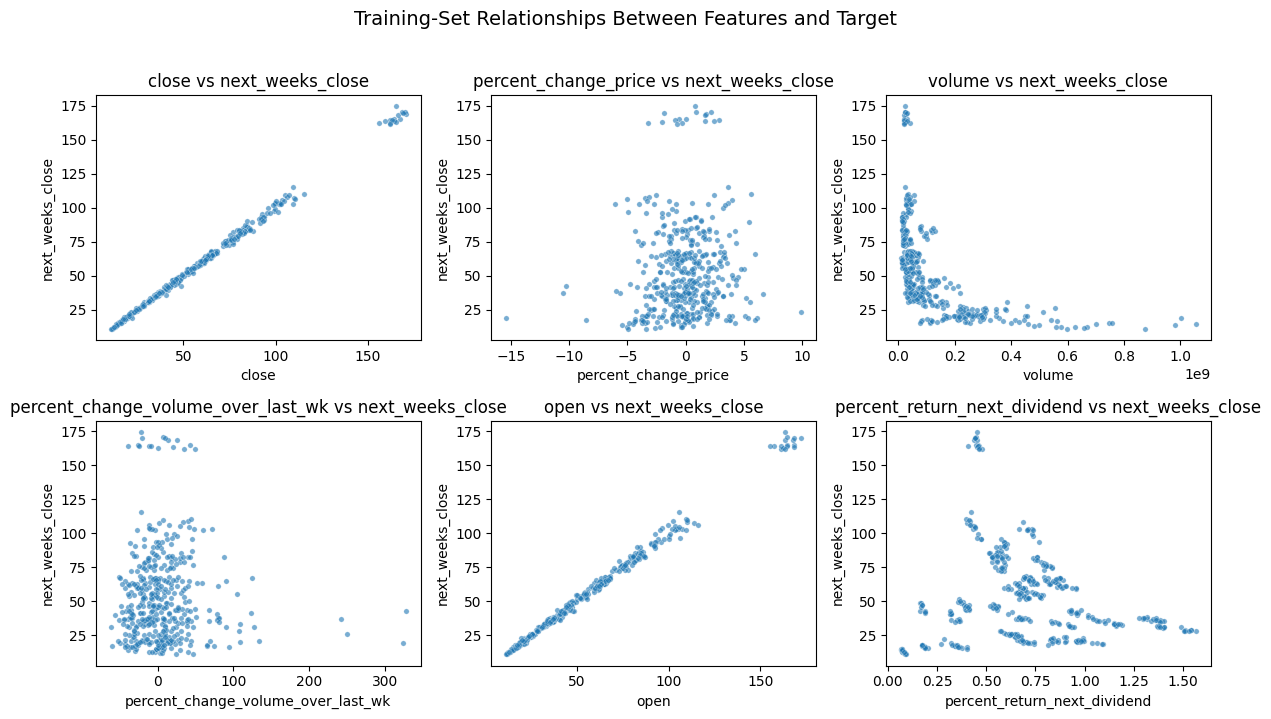

In [11]:
from sklearn.model_selection import train_test_split

raw = pd.read_csv('dataset.csv', na_values='?')
raw[price_cols] = raw[price_cols].astype(str).replace(r'[\$,]', '', regex=True).astype(float)

raw = (raw
       .drop(['stock', 'quarter', 'date',
              'next_weeks_open', 'percent_change_next_weeks_price'], axis=1)
       .dropna()
       .reset_index(drop=True))

X_full = raw.drop(columns=['next_weeks_close'])
y_full = raw['next_weeks_close']
X_train, _, y_train, _ = train_test_split(X_full, y_full,
                                          test_size=0.40,
                                          random_state=42,
                                          shuffle=True)

train = X_train.copy()
train['next_weeks_close'] = y_train

features = [
    'close',
    'percent_change_price',
    'volume',
    'percent_change_volume_over_last_wk',
    'open',
    'percent_return_next_dividend'
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()

for ax, feat in zip(axes, features):
    sns.scatterplot(data=train, x=feat, y='next_weeks_close',
                    s=15, alpha=0.6, ax=ax)
    ax.set_title(f'{feat} vs next_weeks_close')

plt.suptitle('Training-Set Relationships Between Features and Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Linear Regression

## Preprocessing

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset.csv', na_values='?')
price_cols = ['open','high','low','close','next_weeks_open','next_weeks_close']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

df = df.drop(['stock','quarter','date','next_weeks_open','percent_change_next_weeks_price'], axis=1).dropna()

X = df.drop(columns='next_weeks_close')
y = df['next_weeks_close']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Shapes: (432, 10) (144, 10) (144, 10)


## Modeling Across Transformations

apply feature sets:

1. Original standardized features
2. Polynomial features (degree=2)
3. PCA (95% variance)
4. SelectKBest (top 5 features)

In [2]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

transformers = {
    'original': None,
    'polynomial': PolynomialFeatures(degree=2, include_bias=False),
    'pca': PCA(n_components=0.95, random_state=42),
    'kbest': SelectKBest(score_func=f_regression, k=5)
}

alphas = [0.01, 0.1, 1, 10, 100, 1000]
results = []

for name, transformer in transformers.items():
    if name == 'original':
        Xtr, Xvl, Xts = X_train_scaled, X_val_scaled, X_test_scaled
    else:
        if name == 'polynomial':
            Xt_train = transformer.fit_transform(X_train_scaled)
            Xt_val   = transformer.transform(X_val_scaled)
            Xt_test  = transformer.transform(X_test_scaled)
        else:
            Xt_train = transformer.fit_transform(X_train_scaled, y_train) if name=='kbest' else transformer.fit_transform(X_train_scaled)
            Xt_val   = transformer.transform(X_val_scaled)
            Xt_test  = transformer.transform(X_test_scaled)
        Xtr, Xvl, Xts = Xt_train, Xt_val, Xt_test

    lr = LinearRegression().fit(Xtr, y_train)
    for ds, Xs, ys in [('Train', Xtr, y_train), ('Val', Xvl, y_val)]:
        pred = lr.predict(Xs)
        results.append({
            'Model': 'Linear',
            'Transformation': name,
            'Alpha': None,
            'Dataset': ds,
            'MSE': mean_squared_error(ys, pred),
            'R2': r2_score(ys, pred)
        })

    for alpha in alphas:
        rd = Ridge(alpha=alpha, random_state=42).fit(Xtr, y_train)
        for ds, Xs, ys in [('Train', Xtr, y_train), ('Val', Xvl, y_val)]:
            pred = rd.predict(Xs)
            results.append({
                'Model': 'Ridge',
                'Transformation': name,
                'Alpha': alpha,
                'Dataset': ds,
                'MSE': mean_squared_error(ys, pred),
                'R2': r2_score(ys, pred)
            })

results_df = pd.DataFrame(results)
results_df

,Model,Transformation,Alpha,Dataset,MSE,R2
0,Linear,original,NaN,Train,2.305467,0.997928
1,Linear,original,NaN,Val,2.914730,0.997611
2,Ridge,original,0.01,Train,2.307433,0.997926
3,Ridge,original,0.01,Val,2.910114,0.997615
4,Ridge,original,0.10,Train,2.372407,0.997868
5,Ridge,original,0.10,Val,2.951095,0.997581
6,Ridge,original,1.00,Train,2.561898,0.997697
7,Ridge,original,1.00,Val,3.132547,0.997433
8,Ridge,original,10.00,Train,2.679697,0.997592
9,Ridge,original,10.00,Val,3.187666,0.997387


## Results Visualization

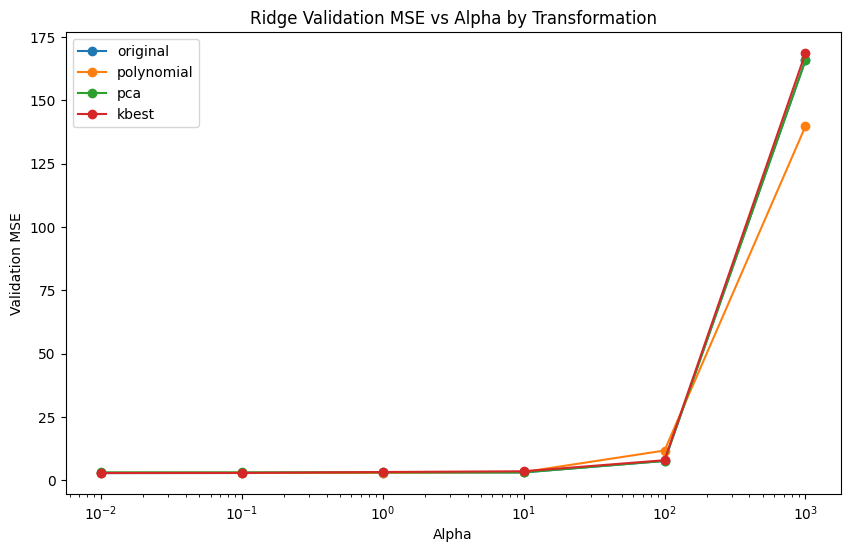

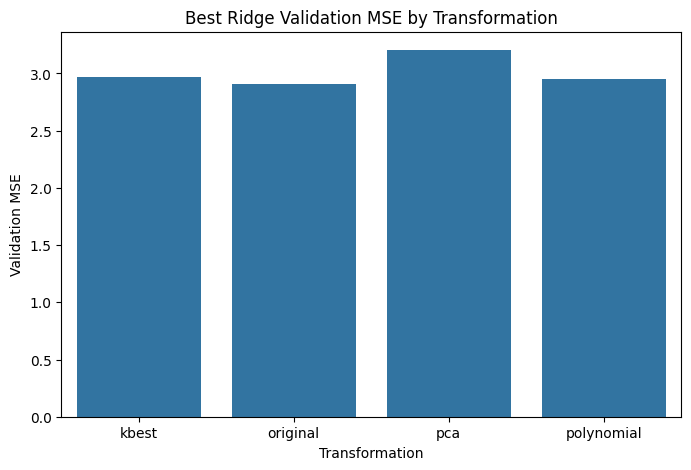

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

ridge_val = results_df[(results_df.Model=='Ridge') & (results_df.Dataset=='Val')]

plt.figure(figsize=(10, 6))
for name in transformers.keys():
    subset = ridge_val[ridge_val.Transformation==name]
    plt.plot(subset.Alpha, subset.MSE, marker='o', label=name)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Validation MSE')
plt.title('Ridge Validation MSE vs Alpha by Transformation')
plt.legend()
plt.show()

best_ridge = ridge_val.loc[ridge_val.groupby('Transformation').MSE.idxmin()]
plt.figure(figsize=(8, 5))
sns.barplot(data=best_ridge, x='Transformation', y='MSE')
plt.title('Best Ridge Validation MSE by Transformation')
plt.ylabel('Validation MSE')
plt.show()

## Final Model Selection and Test Evaluation

In [4]:
best_idx = ridge_val.MSE.idxmin()
best_cfg = ridge_val.loc[best_idx]
print("Best configuration:", best_cfg)

from numpy import vstack
X_full = vstack([X_train_scaled, X_val_scaled])
Y_full = pd.concat([y_train, y_val])

best_name = best_cfg.Transformation
best_alpha = best_cfg.Alpha
if best_name=='original':
    XF, XT = X_full, X_test_scaled
elif best_name=='polynomial':
    poly = PolynomialFeatures(degree=2, include_bias=False)
    XF = poly.fit_transform(X_full)
    XT = poly.transform(X_test_scaled)
elif best_name=='pca':
    pca = PCA(n_components=0.95, random_state=42)
    XF = pca.fit_transform(X_full)
    XT = pca.transform(X_test_scaled)
else:
    kbest = SelectKBest(score_func=f_regression, k=5)
    XF = kbest.fit_transform(X_full, Y_full)
    XT = kbest.transform(X_test_scaled)

final_model = Ridge(alpha=best_alpha, random_state=42).fit(XF, Y_full)
pred_test = final_model.predict(XT)
from sklearn.metrics import mean_squared_error, r2_score
print("Test MSE:", mean_squared_error(y_test, pred_test))
print("Test R2:", r2_score(y_test, pred_test))

Best configuration: Model                Ridge
Transformation    original
Alpha                 0.01
Dataset                Val
MSE               2.910114
R2                0.997615
Name: 3, dtype: object
Test MSE: 2.5116482780767146
Test R2: 0.9972456434614503


# Support Vector Regression (SVR) Supervised Learning

## Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

## Load and preprocess data

In [4]:
# Load dataset
df = pd.read_csv("dataset.csv")

# One-hot encode 'stock' column
df = pd.get_dummies(df, columns=['stock'])

# Remove leaking columns
df.drop(['next_weeks_open', 'percent_change_next_weeks_price'], axis=1, inplace=True)

# Replace missing values in specified columns
cols = ['previous_weeks_volume', 'percent_change_volume_over_last_wk']
df[cols] = df[cols].replace('?', 0)

# Handle date column
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.drop('date', axis=1, inplace=True)

# Convert dollar strings to floats
for col in df.select_dtypes(include='object').columns:
    if df[col].str.contains('^\$').any():
        df[col] = df[col].str.replace('[$,]', '', regex=True).astype(float)

# Move target to the end
y = df.pop('next_weeks_close').values
X = df.values

# Split into train+val and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Further split train+val into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# Scale features
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

# Scale target
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()

<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
/var/folders/16/22h86xpd7j33w8md_8shh5gh0000gn/T/ipykernel_91280/1831441041.py:23: SyntaxWarning: invalid escape sequence '\$'
  if df[col].str.contains('^\$').any():


## Define feature transformations and hyperparameter grid

In [5]:
C_values = [0.01, 0.1, 1, 10, 100, 1000]
transformers = {
    'Polynomial (degree=2)': PolynomialFeatures(degree=2, include_bias=False),
    'PCA (95% variance)': PCA(n_components=0.95, random_state=42),
    'RBFSampler (gamma=1)': RBFSampler(gamma=1, random_state=42)
}

## Run experiments

In [ ]:
results = []
for name, transformer in transformers.items():
    # Apply transformation
    X_tr = transformer.fit_transform(X_train_scaled)
    X_vl = transformer.transform(X_val_scaled)
    X_te = transformer.transform(X_test_scaled)

    # Re-scale after transformation
    scaler_t = StandardScaler()
    X_tr = scaler_t.fit_transform(X_tr)
    X_vl = scaler_t.transform(X_vl)
    X_te = scaler_t.transform(X_te)

    for C in C_values:
        # Use linear kernel after explicit feature mapping
        svr = SVR(kernel='linear', C=C)
        svr.fit(X_tr, y_train_scaled)

        # Predictions (scaled)
        y_tr_pred = svr.predict(X_tr)
        y_vl_pred = svr.predict(X_vl)

        # Inverse-transform to original scale
        y_tr_orig = y_scaler.inverse_transform(y_tr_pred.reshape(-1, 1)).ravel()
        y_vl_orig = y_scaler.inverse_transform(y_vl_pred.reshape(-1, 1)).ravel()

        # Compute metrics
        mse_tr = mean_squared_error(y_train, y_tr_orig)
        mse_vl = mean_squared_error(y_val, y_vl_orig)
        r2_tr = r2_score(y_train, y_tr_orig)
        r2_vl = r2_score(y_val, y_vl_orig)

        results.append({
            'transformation': name,
            'C': C,
            'mse_train': mse_tr,
            'mse_val': mse_vl,
            'r2_train': r2_tr,
            'r2_val': r2_vl
        })

# Convert to DataFrame and save
df_results = pd.DataFrame(results)
df_results.to_csv('svr_experiment_results.csv', index=False)
df_results.head()

,transformation,C,mse_train,mse_val,r2_train,r2_val
0,Polynomial (degree=2),0.01,5.721927,8.051109,0.994750,0.992374
1,Polynomial (degree=2),0.10,5.629736,8.919860,0.994835,0.991551
2,Polynomial (degree=2),1.00,5.629736,8.919860,0.994835,0.991551
3,Polynomial (degree=2),10.00,5.629736,8.919860,0.994835,0.991551
4,Polynomial (degree=2),100.00,5.629736,8.919860,0.994835,0.991551


In [ ]:
## 6. Test‐Set Evaluation for SVR

best_row = df_results.loc[df_results['r2_val'].idxmax()]
best_transformation = best_row['transformation']
best_C = best_row['C']
# 1) Refit best SVR on train+val
svr_final = SVR(kernel='linear', C=best_C)
svr_final.fit(X_train_scaled, y_train_scaled)

# 2) Predict on test (scaled)
y_test_pred_scaled = svr_final.predict(X_test_scaled)

# 3) Inverse‐transform to original units
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1,1)).ravel()

# 4) Compute metrics
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test  = r2_score(y_test,  y_test_pred)

print(f"Test MSE: {mse_test:.4f}")
print(f"Test  R²: { r2_test:.4f}")

Test MSE: 4.8218
Test  R²: 0.9956


## Plot performance vs. Regularization

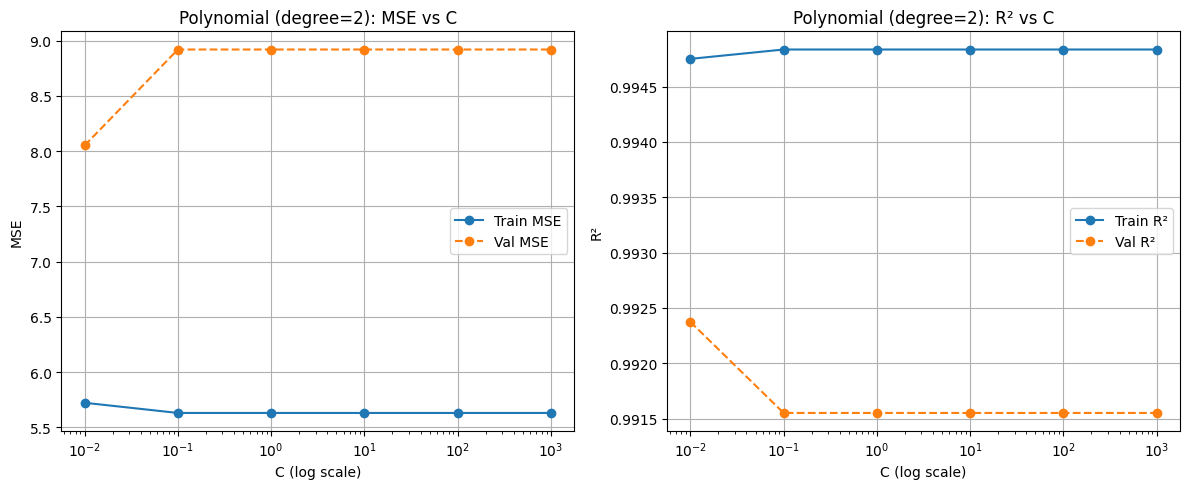

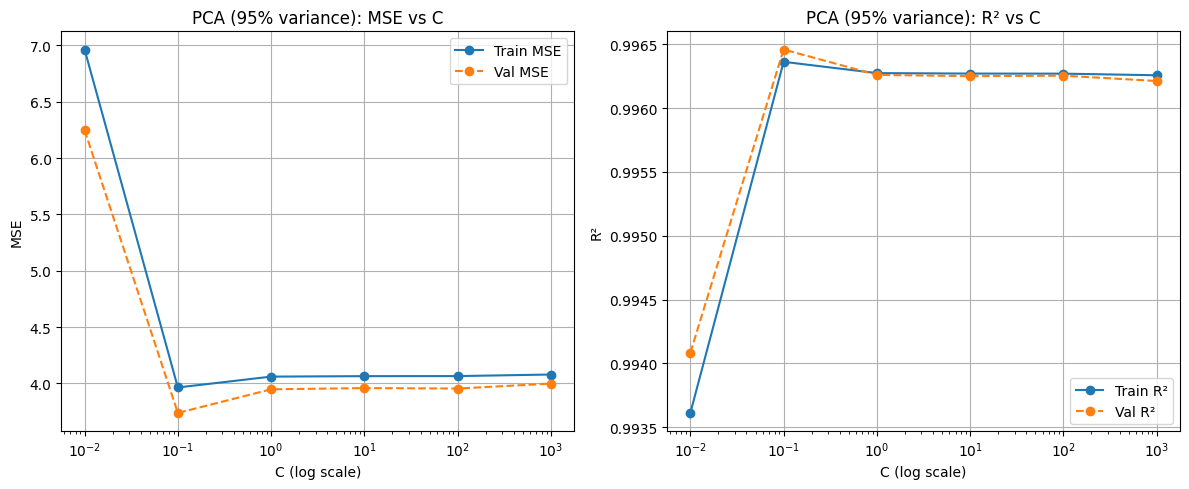

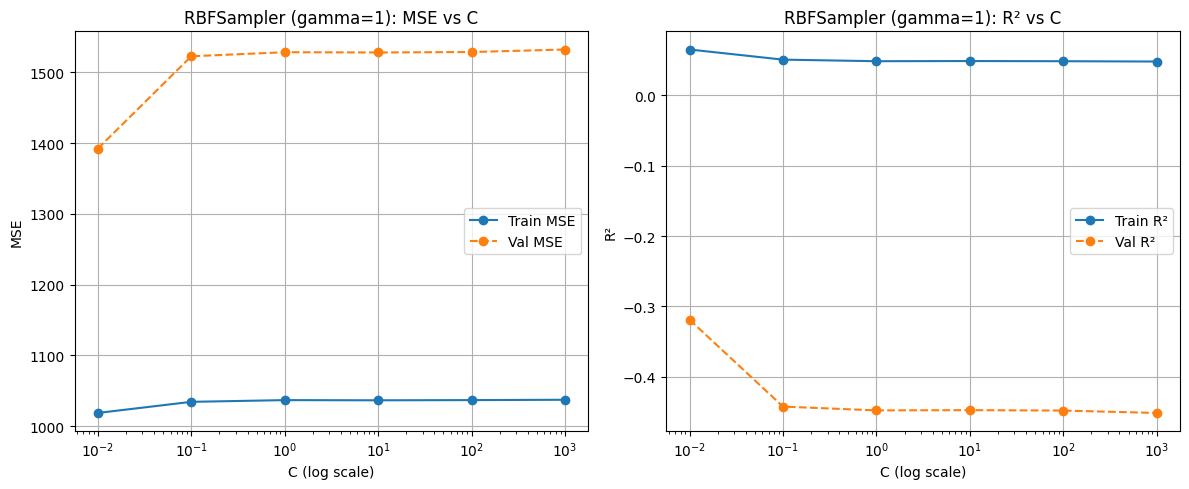

In [5]:
for name in transformers.keys():
    subset = df_results[df_results['transformation'] == name]
    subset = subset.sort_values('C')

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(subset['C'], subset['mse_train'], marker='o', label='Train MSE')
    plt.plot(subset['C'], subset['mse_val'], marker='o', linestyle='--', label='Val MSE')
    plt.xscale('log')
    plt.xlabel('C (log scale)')
    plt.ylabel('MSE')
    plt.title(f"{name}: MSE vs C")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(subset['C'], subset['r2_train'], marker='o', label='Train R²')
    plt.plot(subset['C'], subset['r2_val'], marker='o', linestyle='--', label='Val R²')
    plt.xscale('log')
    plt.xlabel('C (log scale)')
    plt.ylabel('R²')
    plt.title(f"{name}: R² vs C")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Import All The Libraries


In [2]:
from sklearn.preprocessing import StandardScaler  
from sklearn.model_selection import train_test_split  
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import copy
import torch
import tqdm

# Format and Adjust Data

In [ ]:
df = pd.read_csv("dataset.csv")

df = pd.get_dummies(df, columns=['stock'])

df.pop('next_weeks_open') 
df.pop('percent_change_next_weeks_price')

cols = ['previous_weeks_volume','percent_change_volume_over_last_wk']
df[cols] = df[cols].replace('?',0)

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
temp_date = df.pop('date')

df = df.replace('\$','',regex=True).astype(float)


y_col = df.pop('next_weeks_close')
df.insert(len(df.columns), 'next_weeks_close', y_col)

<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
/var/folders/16/22h86xpd7j33w8md_8shh5gh0000gn/T/ipykernel_79406/2910099702.py:24: SyntaxWarning: invalid escape sequence '\$'
  df = df.replace('\$','',regex=True).astype(float)


## Scale the dataset

In [ ]:
data = df.to_numpy()

X = data[:, :-1]
y = data[:, -1].reshape(-1, 1)

x_scalar = StandardScaler()
y_scalar = StandardScaler()

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, shuffle=True, random_state=42)

X_train = x_scalar.fit_transform(X_train)
X_val = x_scalar.transform(X_val)
X_test = x_scalar.transform(X_test)

y_train = y_scalar.fit_transform(y_train)
y_val = y_scalar.transform(y_val)
y_test = y_scalar.transform(y_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Create NN Models 

In [ ]:
# Model 1: Simple 1-hidden-layer NN
model1 = nn.Sequential(
    nn.Linear(44, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# Model 2: 2 layers with dropout and mixed activations
model2 = nn.Sequential(
    nn.Linear(44, 32),
    nn.ELU(),
    nn.Dropout(0.3),
    nn.Linear(32, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

# Model 3: Deeper, mild regularization
model3 = nn.Sequential(
    nn.Linear(44, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ELU(),
    nn.Dropout(0.2),
    nn.Linear(32, 1)
)

# Train Models

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import r2_score
import pandas as pd

results = []

def train_model(model, X_train, y_train, X_val, y_val, l2_val, y_scalar, model_name="Model"):
    n_epochs = 500
    batch_size = 32
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=l2_val)

    for epoch in range(n_epochs):
        model.train()
        permutation = torch.randperm(X_train.size()[0])
        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            X_batch, y_batch = X_train[indices], y_train[indices]

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train).detach().numpy()
        y_pred_val = model(X_val).detach().numpy()

        y_pred_train_unscaled = y_scalar.inverse_transform(y_pred_train)
        y_train_unscaled = y_scalar.inverse_transform(y_train.numpy())

        y_pred_val_unscaled = y_scalar.inverse_transform(y_pred_val)
        y_val_unscaled = y_scalar.inverse_transform(y_val.numpy())

        train_r2 = r2_score(y_train_unscaled, y_pred_train_unscaled)
        val_r2 = r2_score(y_val_unscaled, y_pred_val_unscaled)

        train_mse = loss_fn(torch.tensor(y_pred_train), y_train).item()
        val_mse = loss_fn(torch.tensor(y_pred_val), y_val).item()

        best_metrics = {
            "model": model_name,
            "l2_val": l2_val,
            "train_mse": train_mse,
            "val_mse": val_mse,
            "train_r2": train_r2,
            "val_r2": val_r2
        }

    return best_metrics

# Create Evaluation Model 

# Test different regularization values and models

In [22]:
def run_regularization_experiments(models, weight_decay_values):
    all_results = []

    for i in range(len(models)):
        for weight_decay in weight_decay_values:
            model_name = f"model_{i}"
            print(f"\n=== Training {model_name} ===")

            metrics = train_model(models[i], X_train, y_train, X_val, y_val, weight_decay,y_scalar, model_name=model_name)
            all_results.append(metrics)

    return all_results

# Run tests

In [ ]:
weight_decay_values = [t 1e-4, 1e-3, 1e-2, 0.1, 1.0, 5.0, 10.0]
models = [model1,model2,model3]

results = run_regularization_experiments(models, weight_decay_values)
    
df_results = pd.DataFrame(results)
df_results.to_csv("regression_results.csv", index=False)
print("Saved to regression_results.csv")


=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===
Saved to regression_results.csv


In [ ]:
## 6. Evaluate Neural Nets on Test Set (Corrected)

from sklearn.metrics import mean_squared_error, r2_score

# 1) Combine train+val for final training
X_full = torch.cat([X_train, X_val], dim=0)
y_full = torch.cat([y_train, y_val], dim=0)

test_results = []
for i, base_model in enumerate([model1, model2, model3]):
    for wd in weight_decay_values:
        # Re-init and train on full data
        model = copy.deepcopy(base_model)
        optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=wd)
        loss_fn = nn.MSELoss()
        
        for epoch in range(500):
            model.train()
            perm = torch.randperm(X_full.size(0))
            for b in range(0, X_full.size(0), 32):
                idx = perm[b:b+32]
                xb, yb = X_full[idx], y_full[idx]
                pred = model(xb)
                loss = loss_fn(pred, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # 2) Predict on TEST
        model.eval()
        with torch.no_grad():
            y_pred_scaled = model(X_test).numpy()

        # 3) Inverse‐scale to original units
        y_pred = y_scalar.inverse_transform(y_pred_scaled)
        y_true = y_scalar.inverse_transform(y_test.numpy())

        # 4) Compute metrics with sklearn
        test_mse = mean_squared_error(y_true, y_pred)
        test_r2  = r2_score(y_true, y_pred)

        test_results.append({
            'model':   f'model_{i}',
            'l2_val':   wd,
            'test_mse': test_mse,
            'test_r2':  test_r2
        })

# 5) Summarize
df_test = pd.DataFrame(test_results)
print(df_test)
df_test.to_csv('nn_test_results.csv', index=False)

      model   l2_val     test_mse   test_r2
0   model_0   0.0000     2.717650  0.997548
1   model_0   0.0001     2.757875  0.997512
2   model_0   0.0010     2.622058  0.997634
3   model_0   0.0100     2.777534  0.997494
4   model_0   0.1000     6.289325  0.994326
5   model_0   1.0000   184.769455  0.833301
6   model_0   5.0000  1108.557251 -0.000139
7   model_0  10.0000  1108.523071 -0.000109
8   model_1   0.0000     3.332332  0.996994
9   model_1   0.0001     3.122923  0.997182
10  model_1   0.0010     3.086564  0.997215
11  model_1   0.0100     3.311012  0.997013
12  model_1   0.1000  1108.874512 -0.000426
13  model_1   1.0000  1108.762329 -0.000324
14  model_1   5.0000  1108.623779 -0.000199
15  model_1  10.0000  1108.548950 -0.000132
16  model_2   0.0000     5.454027  0.995079
17  model_2   0.0001     5.068806  0.995427
18  model_2   0.0010     3.620918  0.996733
19  model_2   0.0100     4.317260  0.996105
20  model_2   0.1000  1108.876343 -0.000427
21  model_2   1.0000  1108.72204

# Plotting results 

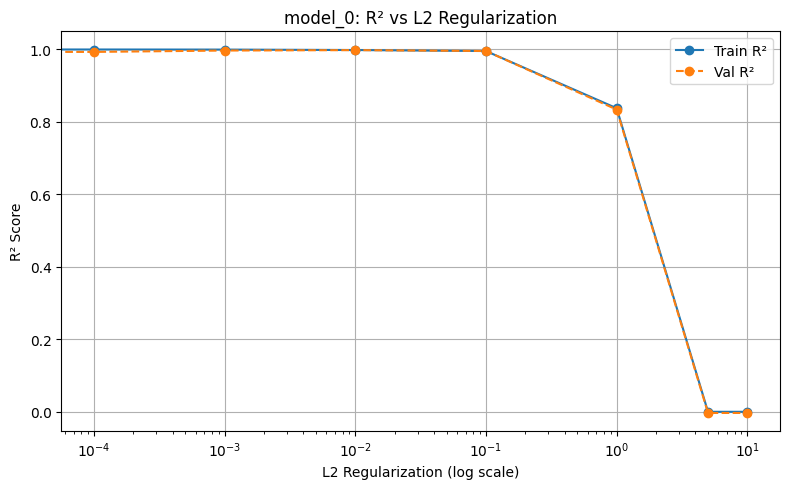

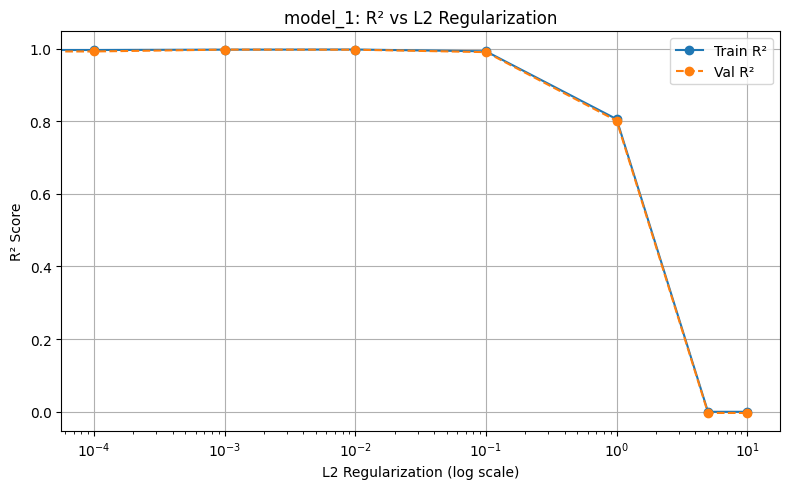

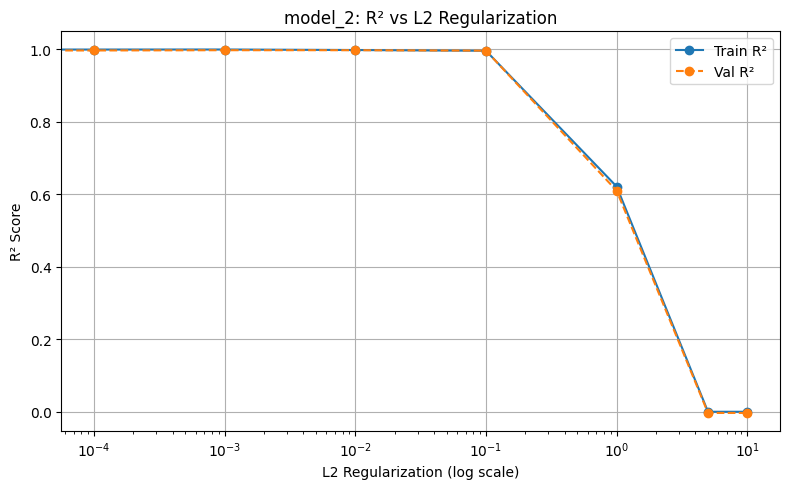

In [ ]:
for model_index in [0, 1, 2]:
    model_name = f"model_{model_index}"
    subset = df_results[df_results['model'].str.contains(model_name)]
    
    subset = subset.sort_values(by='l2_val')
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(subset['l2_val'], subset['train_r2'], marker='o', label='Train R²')
    plt.plot(subset['l2_val'], subset['val_r2'], marker='o', linestyle='--', label='Val R²')

    plt.xscale('log')
    plt.xlabel('L2 Regularization (log scale)')
    plt.ylabel('R² Score')
    plt.title(f"{model_name}: R² vs L2 Regularization")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()